# GeoCarb Observation Geometry — `geosat_geometry` Driver Notebook

This notebook walks through every major feature of `geosat_geometry.py` and
`model_sampler.py`, following the natural separation between time-independent
geometry and time-dependent solar angles.

**Time-independent** (computed once per scan region, reusable):
lats, lons, VZAs, VAAs, look vectors, footprint corners, ray paths.

**Time-dependent** (stamped onto a template for any desired start time):
SZAs, SAAs, airmass, relative azimuth.

1. [Satellite setup](#1-satellite-setup)
2. [Single slit geometry](#2-single-slit-geometry)
3. [Building scan templates](#3-building-scan-templates)
4. [Exploring ScanBlock structure](#4-exploring-scanblock-structure)
5. [Plotting time-independent fields](#5-plotting-time-independent-fields)
6. [Save and reload](#6-save-and-reload)
7. [Coarsening to a model grid](#7-coarsening-to-a-model-grid)
8. [Fine vs coarse comparison](#8-fine-vs-coarse-comparison)
9. [3-D ray tracing through the atmosphere](#9-3-d-ray-tracing-through-the-atmosphere)
10. [Ray tracing from a ScanBlock](#10-ray-tracing-from-a-scanblock)
11. [Time-stamping — applying a start time](#11-time-stamping--applying-a-start-time)
12. [Solar geometry through the day](#12-solar-geometry-through-the-day)
13. [Scan direction — W2E vs E2W](#13-scan-direction--w2e-vs-e2w)
14. [Chaining scan templates](#14-chaining-scan-templates)
15. [Observation sequence — time-ordered timeline](#15-observation-sequence--time-ordered-timeline)
16. [Sampling a 3-D model field (regular grid)](#16-sampling-a-3-d-model-field-regular-grid)
17. [Per-pixel altitude levels (hybrid-sigma / terrain-following)](#17-per-pixel-altitude-levels-hybrid-sigma--terrain-following)
18. [Curvilinear grid, 4-D fields, and limited-area domains](#18-curvilinear-grid-4-d-fields-and-limited-area-domains)

---
## 1 — Satellite Setup

Configure a GeoCarb-like instrument at −85° longitude with a 3000 km N-S slit,
6 km × 3 km pixels, and a 10-second integration time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime, timedelta
import time
import cartopy.crs as ccrs
from importlib import reload
import geosat_geometry
reload(geosat_geometry)

from geosat_geometry import (
    LongSlitGeoSatellite,
    ScanBlock,
    chain_scan_blocks,
    plot_scan_blocks,
    coarsen_scan_block,
    geodetic_to_ecef,
    ecef_to_geodetic,
    solar_position_ecef,
)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
sat = LongSlitGeoSatellite(
    sat_lon_deg      = -85.0,   # sub-satellite longitude [°E]
    slit_length_km   = 3000.0,  # N-S slit length at nadir [km]
    pixel_size_ew_km =    6.0,  # E-W pixel size at nadir [km]
    pixel_size_ns_km =    3.0,  # N-S pixel size at nadir [km]
    integration_time_s = 10.0,  # one scan step [s]
)
print(sat)
print(f"  Satellite ECEF [km] : {sat.sat_ecef.round(1)}")
print(f"  Pixels along slit   : {sat.n_pixels}")
print(f"  IFOV E-W / N-S      : {np.degrees(sat.ifov_ew_rad)*60:.3f} / "
      f"{np.degrees(sat.ifov_ns_rad)*60:.3f} arcmin")
print(f"  Scan rate           : {sat.scan_rate_kms:.4f} km/s")

LongSlitGeoSatellite(lon=-85.0°, slit=3000 km × 1000 px, pixel=3.0×6.0 km, τ=10.0s)
  Satellite ECEF [km] : [  3674.8 -42003.7      0. ]
  Pixels along slit   : 1000
  IFOV E-W / N-S      : 0.576 / 0.288 arcmin
  Scan rate           : 0.6000 km/s


---
## 2 — Single Slit Geometry

`slit_geometry_vectorized` computes the geometry for all pixels in one slit
position.  Here we show the purely spatial fields (VZA, VAA) which require no
UTC time.  Solar angles (SZA, SAA) are introduced in §11 after time-stamping.

In [3]:
# No UTC time — viewing geometry only
geom = sat.slit_geometry_vectorized(30.0, -100.0)

print("Slit geometry keys:", list(geom.keys()))
print(f"\nSouth pixel  lat={geom['lats'][ 0]:.2f}°  VZA={geom['vzas'][ 0]:.1f}°")
print(f"Centre pixel lat={geom['lats'][500]:.2f}°  VZA={geom['vzas'][500]:.1f}°")
print(f"North pixel  lat={geom['lats'][-1]:.2f}°  VZA={geom['vzas'][-1]:.1f}°")
print(f"\nSZA all NaN (no time given): {np.all(np.isnan(geom['szas']))}")

Slit geometry keys: ['lats', 'lons', 'vzas', 'vaas', 'szas', 'saas', 'look_vecs', 'sat_look_vecs', 'corner_lats', 'corner_lons', 'gnd_ecef', 'sat_ecef', 'airmass_geometric', 'relative_azimuth', 'valid_mask']

South pixel  lat=14.54°  VZA=22.9°
Centre pixel lat=30.02°  VZA=38.6°
North pixel  lat=51.07°  VZA=62.0°

SZA all NaN (no time given): True


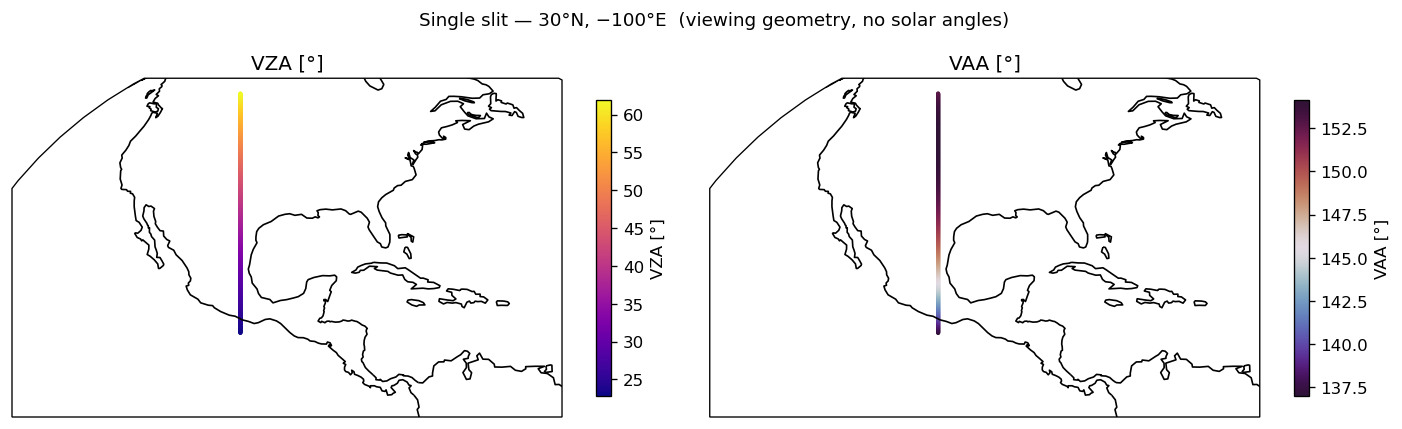

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True,
                          subplot_kw={'projection': ccrs.Geostationary(
                              central_longitude=sat.sat_lon_deg, satellite_height=35_786_000)})
for ax, fld, lbl, cm in zip(axes, ['vzas', 'vaas'],
                              ['VZA [°]', 'VAA [°]'], ['plasma', 'twilight_shifted']):
    sc = ax.scatter(geom['lons'], geom['lats'], c=geom[fld], s=2, cmap=cm,
                    transform=ccrs.PlateCarree(),
                    norm=mcolors.Normalize(vmin=np.nanmin(geom[fld]),
                                          vmax=np.nanmax(geom[fld])))
    plt.colorbar(sc, ax=ax, label=lbl, shrink=0.85)
    ax.set_title(lbl)
    ax.coastlines()
    ax.set_extent([-130, -60, 5, 55], crs=ccrs.PlateCarree())
plt.suptitle('Single slit — 30°N, −100°E  (viewing geometry, no solar angles)',
             y=1.02, fontsize=11)
plt.tight_layout()

---
## 3 — Building Scan Templates

`build_scan_template` computes the full 2-D spatial geometry for a rectangular
scan region — lats, lons, VZAs, VAAs, look vectors, footprint corners — in a
single vectorised pass.  Solar angles are **not** computed; they remain NaN
until a start time is stamped on (§11).

This separation means geometry is computed once and reused for any start time,
scan cycle, or repeat observation.

In [5]:
# Three adjacent templates covering the continental US
region_defs = [
    ('West',    30.0, -120.0,  -95.0),
    ('Central', 30.0,  -95.0,  -75.0),
    ('East',    30.0,  -75.0,  -60.0),
]

t0_build = time.perf_counter()
templates = {}
for name, lat, lon0, lon1 in region_defs:
    templates[name] = sat.build_scan_template(lat, lon0, lon1)
build_ms = (time.perf_counter() - t0_build) * 1e3

print(f"All templates built in {build_ms:.0f} ms")
print()
for name, tmpl in templates.items():
    print(f"{name:8s}: {tmpl}")
    print(f"  VZA {tmpl['vzas'].min():.1f}°–{tmpl['vzas'].max():.1f}°  "
          f"SZA all-NaN: {np.all(np.isnan(tmpl['szas']))}")

All templates built in 224 ms

West    : ScanBlock(1000×402 px | lat=30.0° | lon=[-120.0°,-95.0°] | dur=66.8 min, dir=W2E)
  VZA 19.9°–85.5°  SZA all-NaN: True
Central : ScanBlock(1000×321 px | lat=30.0° | lon=[-95.0°,-75.0°] | dur=53.3 min, dir=W2E)
  VZA 17.2°–59.8°  SZA all-NaN: True
East    : ScanBlock(1000×241 px | lat=30.0° | lon=[-75.0°,-60.0°] | dur=40.0 min, dir=W2E)
  VZA 19.9°–69.2°  SZA all-NaN: True


---
## 4 — Exploring ScanBlock Structure

A `ScanBlock` behaves like a read-only dict of 2-D NumPy arrays.
- **Axis 0** = N-S slit pixels (row 0 = southernmost)
- **Axis 1** = E-W scan steps  (col 0 = westernmost)

Metadata is accessible as attributes.  Fields whose values depend on time
(szas, saas, airmass_geometric, relative_azimuth) are NaN on a template.

In [6]:
tmpl = templates['West']

print("Available fields:", list(tmpl.keys()))
print(f"\nShape (n_rows × n_cols) : {tmpl.shape}")
print(f"Metadata — scan_direction  : {tmpl.scan_direction}")
print(f"Metadata — scan_duration_s : {tmpl.scan_duration_s/60:.1f} min")
print(f"Metadata — t_start_utc     : {tmpl.t_start_utc}  ← NaN until stamped")
print(f"\n2-D array shapes (time-independent):")
for key in ['lats', 'lons', 'vzas', 'vaas']:
    print(f"  {key:20s}: {tmpl[key].shape}")
print(f"2-D array shapes (time-dependent — NaN on template):")
for key in ['szas', 'saas', 'airmass_geometric']:
    print(f"  {key:20s}: {tmpl[key].shape}  (all NaN: {np.all(np.isnan(tmpl[key]))})")
print(f"3-D array shapes:")
for key in ['sat_look_vecs', 'gnd_ecef', 'corner_lats', 'corner_lons']:
    print(f"  {key:20s}: {tmpl[key].shape}")

Available fields: ['lats', 'lons', 'valid_mask', 'vzas', 'vaas', 'szas', 'saas', 'airmass_geometric', 'relative_azimuth', 'sat_look_vecs', 'gnd_ecef', 'corner_lats', 'corner_lons', 'up_vecs', 'east_vecs', 'north_vecs']

Shape (n_rows × n_cols) : (1000, 402)
Metadata — scan_direction  : W2E
Metadata — scan_duration_s : 66.8 min
Metadata — t_start_utc     : None  ← NaN until stamped

2-D array shapes (time-independent):
  lats                : (1000, 402)
  lons                : (1000, 402)
  vzas                : (1000, 402)
  vaas                : (1000, 402)
2-D array shapes (time-dependent — NaN on template):
  szas                : (1000, 402)  (all NaN: True)
  saas                : (1000, 402)  (all NaN: True)
  airmass_geometric   : (1000, 402)  (all NaN: False)
3-D array shapes:
  sat_look_vecs       : (1000, 402, 3)
  gnd_ecef            : (1000, 402, 3)
  corner_lats         : (1000, 402, 4)
  corner_lons         : (1000, 402, 4)


In [7]:
# Pixel-level inspection — centre of the West template
r, c = tmpl.n_rows // 2, tmpl.n_cols // 2
print(f"Centre pixel (row {r}, col {c}):")
print(f"  lat / lon      : {tmpl.lats[r, c]:.3f}° / {tmpl.lons[r, c]:.3f}°")
print(f"  VZA / VAA      : {tmpl.vzas[r, c]:.2f}° / {tmpl.vaas[r, c]:.2f}°")
print(f"  SZA            : {tmpl.szas[r, c]}  ← NaN until stamped")
print(f"  sat_look_vec   : {tmpl.sat_look_vecs[r, c].round(5)}")
print(f"    (norm = {np.linalg.norm(tmpl.sat_look_vecs[r, c]):.6f} — should be 1.0)")
print(f"  footprint NW   : ({tmpl.corner_lats[r, c, 0]:.4f}°, {tmpl.corner_lons[r, c, 0]:.4f}°)")
print(f"  footprint SE   : ({tmpl.corner_lats[r, c, 2]:.4f}°, {tmpl.corner_lons[r, c, 2]:.4f}°)")
ns_size = (tmpl.corner_lats[r,c,0] - tmpl.corner_lats[r,c,2]) * 111.0
ew_size = (tmpl.corner_lons[r,c,1] - tmpl.corner_lons[r,c,0]) * 111.0 * np.cos(np.deg2rad(tmpl.lats[r,c]))
print(f"  footprint size : {ns_size:.2f} km × {ew_size:.2f} km")

Centre pixel (row 500, col 201):
  lat / lon      : 30.017° / -107.474°
  VZA / VAA      : 42.73° / 140.39°
  SZA            : nan  ← NaN until stamped
  sat_look_vec   : [-0.1432   0.98602  0.08515]
    (norm = 1.000000 — should be 1.0)
  footprint NW   : (30.0308°, -107.5047°)
  footprint SE   : (30.0037°, -107.4425°)
  footprint size : 3.00 km × 5.98 km


---
## 5 — Plotting Time-Independent Fields

`plot_scan_blocks` supports three drawing modes:
- `'footprints'` — fill every pixel polygon (most accurate)
- `'pixels'`     — scatter plot at pixel centres (faster for exploration)
- `'outline'`    — block boundary only (fastest, useful for scan planning)

Here we plot VZA and VAA, which are purely geometric.

Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


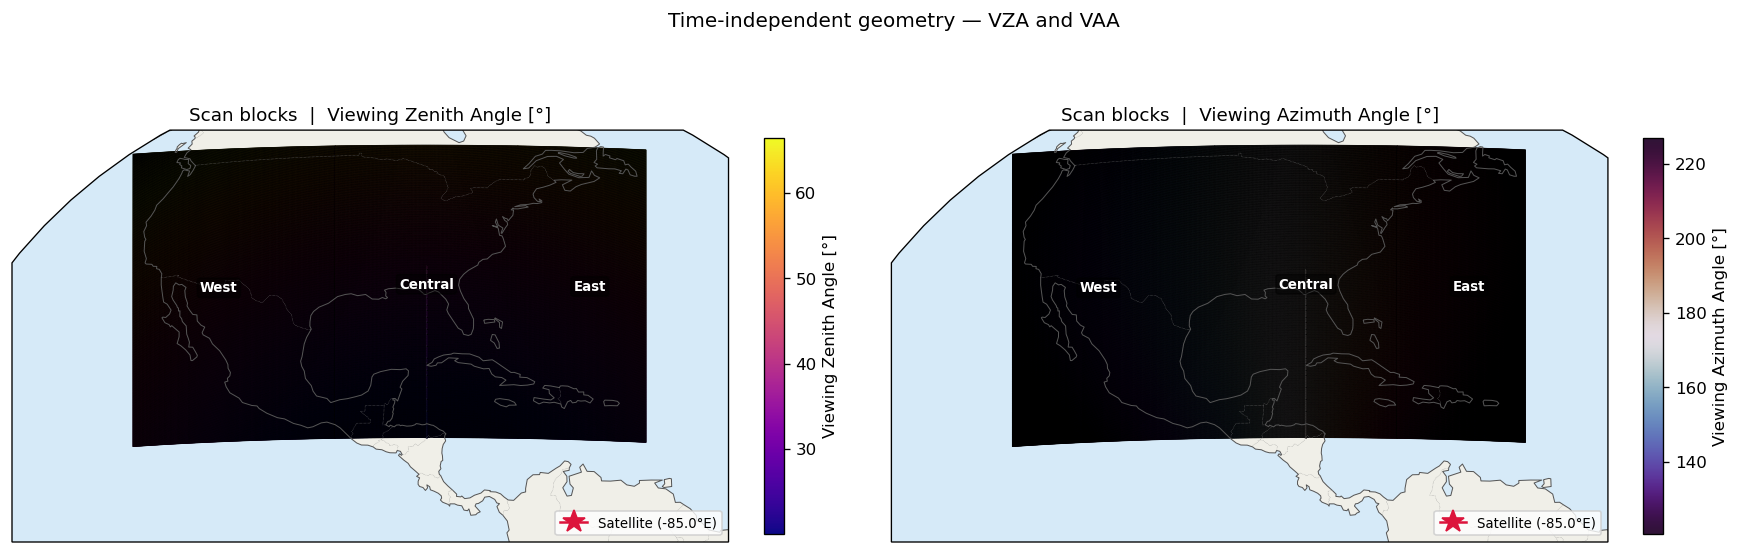

In [8]:
# ---- VZA and VAA side-by-side with footprint polygons ----
sat_lon = sat.sat_lon_deg
_geo = ccrs.Geostationary(central_longitude=sat_lon, satellite_height=35_786_000)
block_list = list(templates.values())
block_names = list(templates.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': _geo})
for ax, fld, cm in zip(axes, ['vzas', 'vaas'], ['plasma', 'twilight_shifted']):
    plot_scan_blocks(block_list, field=fld, mode='footprints',
                     ax=ax, cmap=cm, coastlines=True, block_labels=block_names)
    ax.set_extent([-130, -55, 5, 55], crs=ccrs.PlateCarree())
plt.suptitle('Time-independent geometry — VZA and VAA', y=1.01)
plt.tight_layout()

Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


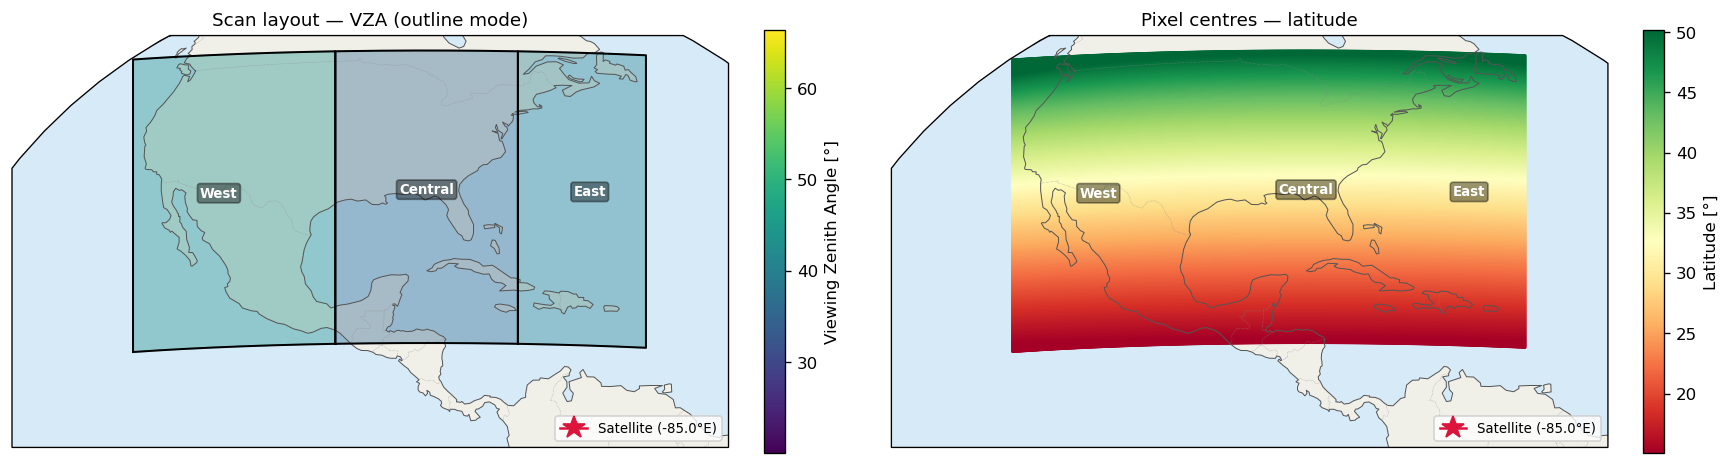

In [9]:
# ---- Scan layout overview with outline mode ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': _geo})
plot_scan_blocks(block_list, field='vzas', mode='outline',
                 ax=axes[0], coastlines=True, block_labels=block_names,
                 title='Scan layout — VZA (outline mode)')
plot_scan_blocks(block_list, field='lats', mode='pixels',
                 ax=axes[1], cmap='RdYlGn', coastlines=True, block_labels=block_names,
                 title='Pixel centres — latitude')
for ax in axes:
    ax.set_extent([-130, -55, 5, 55], crs=ccrs.PlateCarree())
plt.tight_layout()

---
## 6 — Save and Reload

ScanBlocks (including templates) can be persisted to a compressed `.npz` file.
All arrays and metadata round-trip exactly — datetimes are stored as ISO-8601
strings.

In [10]:
import os

save_path = 'west_template.npz'
templates['West'].save(save_path)
size_kb = os.path.getsize(save_path) / 1024
print(f"Saved to {save_path}  ({size_kb:.0f} KB)")

reloaded = ScanBlock.load(save_path)
print(f"Reloaded: {reloaded}")
print(f"  t_start_utc : {reloaded.t_start_utc}  (None — template has no time)")

for field in ['vzas', 'vaas', 'lats', 'lons']:
    diff = np.abs(reloaded[field] - templates['West'][field]).max()
    print(f"  {field:6s}  max |diff| = {diff:.2e}")

Saved to west_template.npz  (64836 KB)
Reloaded: ScanBlock(1000×402 px | lat=30.0° | lon=[-120.0°,-95.0°] | dur=66.8 min, dir=W2E)
  t_start_utc : None  (None — template has no time)
  vzas    max |diff| = 0.00e+00
  vaas    max |diff| = 0.00e+00
  lats    max |diff| = 0.00e+00
  lons    max |diff| = 0.00e+00


---
## 7 — Coarsening to a Model Grid

`block.coarsen(dlat, dlon)` bins the fine 6 km pixels onto a regular lat/lon
grid.  Coarsening is purely spatial and works on templates before any time is
assigned.

Aggregation rules:
- Scalar angles (VZA, airmass) → **arithmetic mean**
- Azimuth angles (VAA) → **circular mean** (handles 0°/360° wrap)
- `sat_look_vecs` → vector-averaged then **renormalised**
- `gnd_ecef` → arithmetic mean of ECEF positions
- `corner_lats/lons` → derived from coarse grid edges directly

In [11]:
# Coarsen all three templates to 0.5° × 0.5°
coarse_templates = {name: tmpl.coarsen(0.5, 0.5)
                    for name, tmpl in templates.items()}

for name, cblk in coarse_templates.items():
    filled   = int((cblk['pixel_counts'] > 0).sum())
    total_px = int(cblk['pixel_counts'].sum())
    print(f"{name:8s}: {cblk}")
    print(f"  {filled} filled cells  |  {total_px:,} fine pixels binned  |  "
          f"mean pixels/cell = {total_px/filled:.1f}")

West    : ScanBlock(81×117 px | lat=34.2° | lon=[-152.0°,-93.5°] | dur=66.8 min [coarsened 0.5°×0.5°])
  4428 filled cells  |  402,000 fine pixels binned  |  mean pixels/cell = 90.8
Central : ScanBlock(73×58 px | lat=32.8° | lon=[-99.5°,-70.5°] | dur=53.3 min [coarsened 0.5°×0.5°])
  3218 filled cells  |  321,000 fine pixels binned  |  mean pixels/cell = 99.8
East    : ScanBlock(76×60 px | lat=33.2° | lon=[-76.5°,-46.5°] | dur=40.0 min [coarsened 0.5°×0.5°])
  2544 filled cells  |  241,000 fine pixels binned  |  mean pixels/cell = 94.7


In [12]:
# Validate coarsening accuracy for spatial fields
print("Field mean comparison (fine vs 0.5° coarse) — West block:")
print(f"{'Field':20s}  {'Fine':>9}  {'Coarse':>9}  {'|Δ|':>8}")
print("-" * 52)
for fld in ['vzas', 'vaas']:
    fine_mean   = float(np.nanmean(templates['West'][fld]))
    coarse_mean = float(np.nanmean(coarse_templates['West'][fld]))
    print(f"{fld:20s}  {fine_mean:9.4f}  {coarse_mean:9.4f}  {abs(fine_mean-coarse_mean):8.4f}")

# Validate unit-vector preservation
slv  = coarse_templates['West']['sat_look_vecs']
mask = np.all(np.isfinite(slv), axis=-1)
norms = np.linalg.norm(slv[mask], axis=-1)
print(f"\nsat_look_vecs norm  min={norms.min():.7f}  max={norms.max():.7f}  (≈1.0)")

# Validate gnd_ecef near-surface altitude
ge = coarse_templates['West']['gnd_ecef']
mask_g = np.all(np.isfinite(ge), axis=-1)
_, _, alts = ecef_to_geodetic(ge[mask_g])
print(f"gnd_ecef altitude   min={alts.min():.3f} km  max={alts.max():.3f} km  (≈0 km)")

Field mean comparison (fine vs 0.5° coarse) — West block:
Field                      Fine     Coarse       |Δ|
----------------------------------------------------
vzas                    44.7429    50.2735    5.5305
vaas                   138.7409   138.6862    0.0547

sat_look_vecs norm  min=1.0000000  max=1.0000000  (≈1.0)
gnd_ecef altitude   min=-0.041 km  max=0.000 km  (≈0 km)


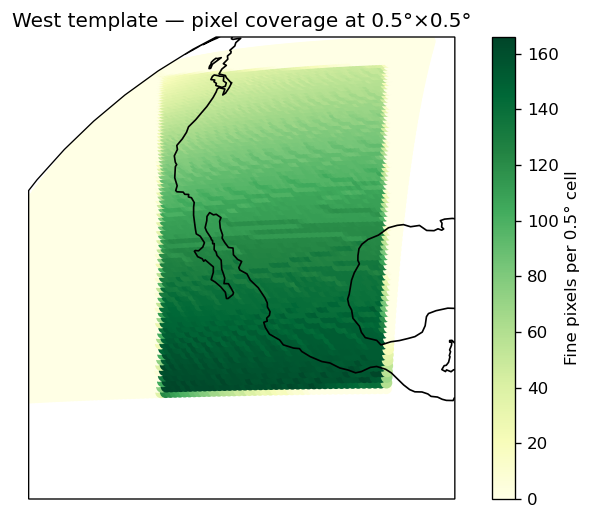

In [13]:
# Pixel count map — shows coverage density per 0.5° cell
cblk = coarse_templates['West']
fig, ax = plt.subplots(figsize=(8, 5),
                        subplot_kw={'projection': ccrs.Geostationary(
                            central_longitude=sat_lon, satellite_height=35_786_000)})
ax.coastlines(); ax.set_global()
im = ax.scatter(cblk['lons'], cblk['lats'],
                c=cblk['pixel_counts'].astype(float),
                cmap='YlGn', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Fine pixels per 0.5° cell')
ax.set_title('West template — pixel coverage at 0.5°×0.5°')
ax.set_extent([-130, -90, 5, 55], crs=ccrs.PlateCarree())

---
## 8 — Fine vs Coarse Comparison

Visually compare the fine-resolution footprints to the coarsened grid, and
compare a range of coarsening resolutions.

Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


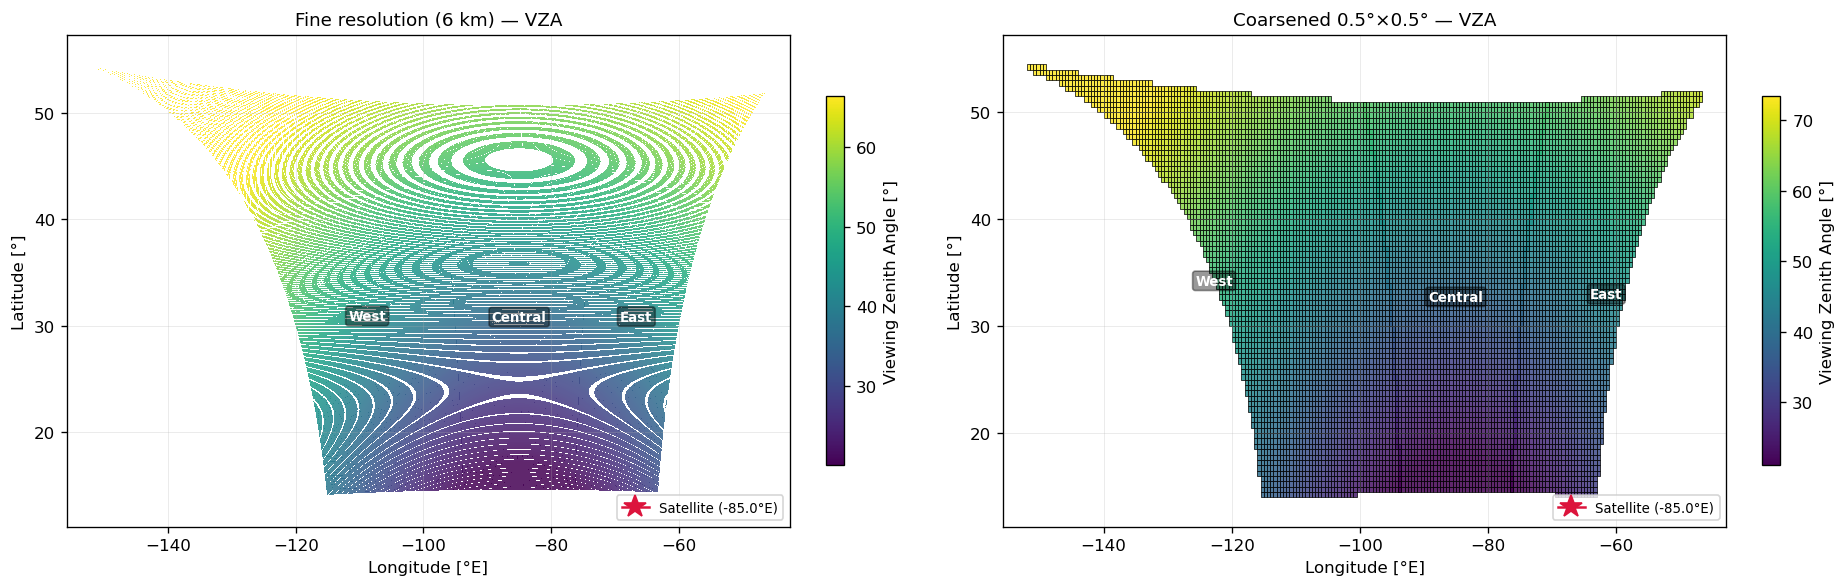

In [14]:
coarse_list = list(coarse_templates.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_scan_blocks(block_list, field='vzas', mode='footprints',
                 ax=axes[0], coastlines=False, block_labels=block_names,
                 title='Fine resolution (6 km) — VZA', outline_lw=0.0)
plot_scan_blocks(coarse_list, field='vzas', mode='footprints',
                 ax=axes[1], coastlines=False, block_labels=block_names,
                 title='Coarsened 0.5°×0.5° — VZA', outline_lw=0.5)
plt.tight_layout()

Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


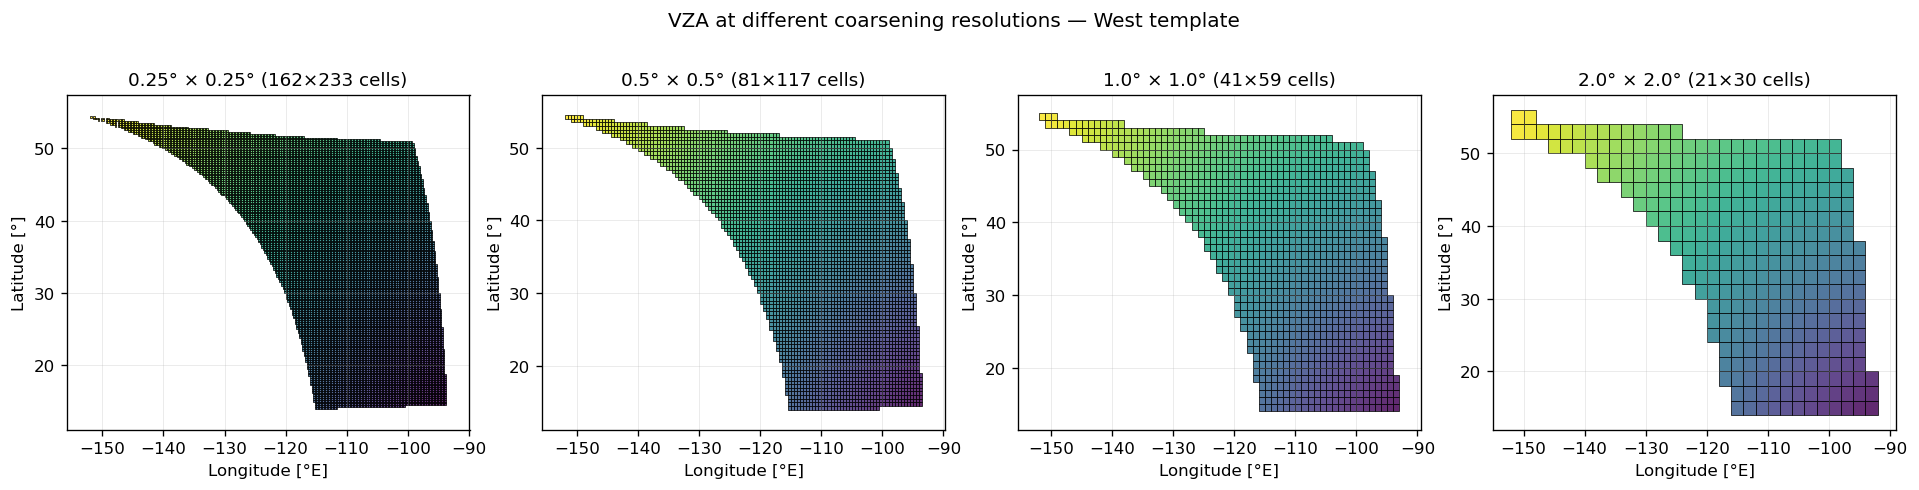

In [15]:
# Compare a range of coarsening resolutions on the West template
resols = [0.25, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, len(resols), figsize=(16, 4))
vmin, vmax = templates['West']['vzas'].min(), templates['West']['vzas'].max()

for ax, res in zip(axes, resols):
    cb = templates['West'].coarsen(res, res)
    plot_scan_blocks(cb, field='vzas', mode='footprints', ax=ax, coastlines=False,
                     vmin=vmin, vmax=vmax, show_sat_subpoint=False,
                     show_colorbar=False, outline_lw=0.5,
                     title=f'{res}° × {res}° ({cb.n_rows}×{cb.n_cols} cells)')
plt.suptitle('VZA at different coarsening resolutions — West template', y=1.01)
plt.tight_layout()

---
## 9 — 3-D Ray Tracing Through the Atmosphere

`compute_ray_paths_vectorized` intersects the satellite-to-ground ray with
spherical atmospheric shells at specified altitudes.  The ray is parameterised
as **P(t) = sat + t × (gnd − sat)**, so t = 0 at the satellite and t = 1 at
the ground.

Ray geometry depends only on pixel lat/lon — no time required.

In [16]:
# Ray paths for every pixel in the West template
tmpl_w = templates['West']
alts   = np.arange(0.0, 80.0, 1.0)   # 80 shells, 1 km spacing

t0_ray = time.perf_counter()
rays = sat.compute_ray_paths_vectorized(
    tmpl_w['lats'].ravel(),
    tmpl_w['lons'].ravel(),
    alts,
)
elapsed = (time.perf_counter() - t0_ray) * 1e3

N = len(tmpl_w['lats'].ravel())
print(f"{N:,} pixels × {len(alts)} shells  →  {elapsed:.0f} ms")
print(f"intercept_pts shape : {rays['intercept_pts'].shape}")
print(f"slant_lengths shape : {rays['slant_lengths'].shape}")

402,000 pixels × 80 shells  →  5920 ms
intercept_pts shape : (402000, 80, 3)
slant_lengths shape : (402000, 79)


In [17]:
# Inspect the ray path for the centre pixel
n_rows, n_cols = tmpl_w.shape
flat_idx = (n_rows // 2) * n_cols + (n_cols // 2)

lat_c = tmpl_w['lats'].ravel()[flat_idx]
lon_c = tmpl_w['lons'].ravel()[flat_idx]
vza_c = tmpl_w['vzas'].ravel()[flat_idx]
print(f"Centre pixel: lat={lat_c:.3f}°  lon={lon_c:.3f}°  VZA={vza_c:.2f}°")
print(f"Expected slant per 1 km layer ≈ 1/cos(VZA) = {1/np.cos(np.deg2rad(vza_c)):.4f} km")
print(f"\n  {'alt':>6}  {'lat':>8}  {'lon':>9}  {'slant [km]':>11}")
for j in range(0, len(alts), 10):
    sl = f"{rays['slant_lengths'][flat_idx, j]:11.4f}" if j < len(alts)-1 else "         ---"
    print(f"  {alts[j]:6.0f}  {rays['lat_intercepts'][flat_idx, j]:8.4f}  "
          f"{rays['lon_intercepts'][flat_idx, j]:9.4f}  {sl}")

Centre pixel: lat=30.017°  lon=-107.474°  VZA=42.73°
Expected slant per 1 km layer ≈ 1/cos(VZA) = 1.3614 km

     alt       lat        lon   slant [km]
       0   29.9832  -107.4413       1.3575
      10   29.9194  -107.3807       1.3557
      20   29.8559  -107.3205       1.3540
      30   29.7926  -107.2606       1.3522
      40   29.7296  -107.2010       1.3505
      50   29.6668  -107.1418       1.3488
      60   29.6042  -107.0829       1.3470
      70   29.5419  -107.0244       1.3453


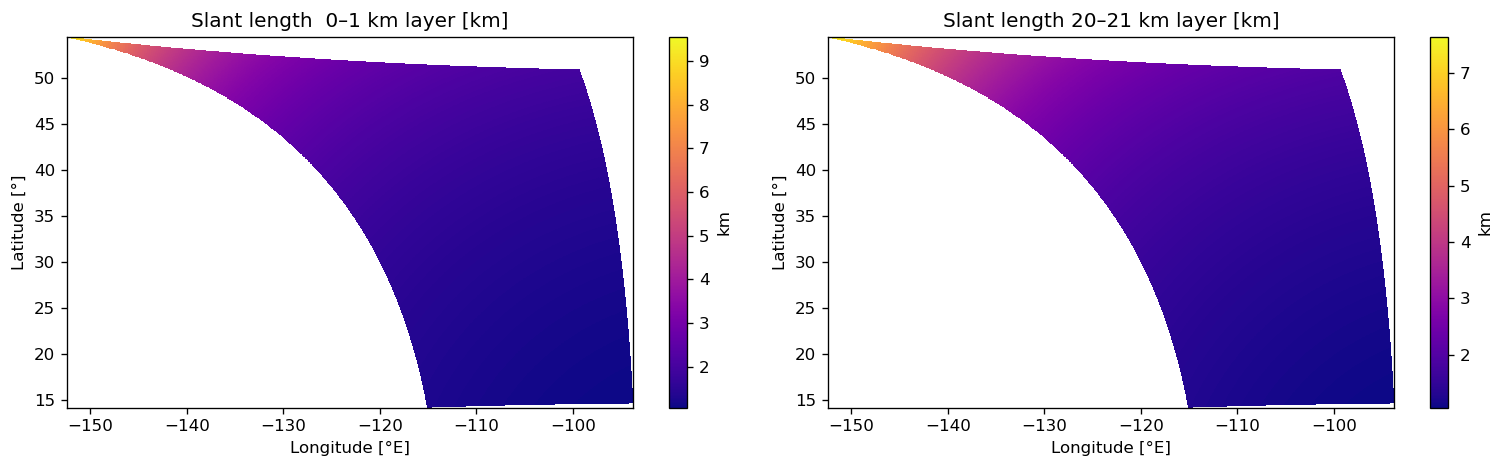

In [18]:
# Slant length maps at two altitude layers
slant_bl = rays['slant_lengths'][:, 0].reshape(n_rows, n_cols)   # 0→1 km
slant_ut = rays['slant_lengths'][:, 20].reshape(n_rows, n_cols)  # 20→21 km

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, title in zip(axes, [slant_bl, slant_ut],
        ['Slant length  0–1 km layer [km]', 'Slant length 20–21 km layer [km]']):
    im = ax.pcolormesh(tmpl_w['lons'], tmpl_w['lats'], data, cmap='plasma', shading='auto')
    plt.colorbar(im, ax=ax, label='km')
    ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°]'); ax.set_title(title)
plt.tight_layout()

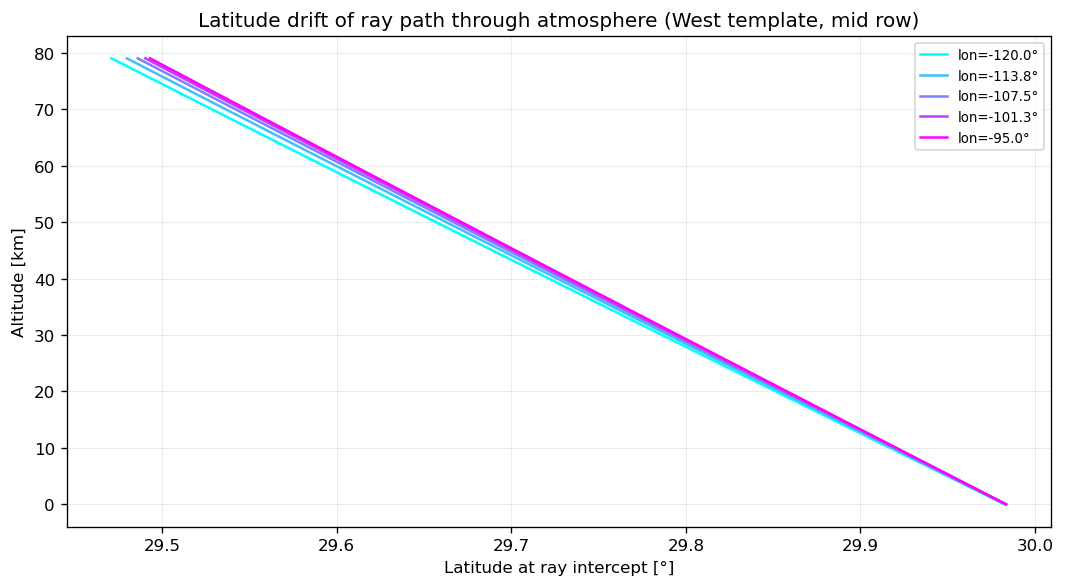

In [19]:
# Side-view: latitude drift of the ray path through the atmosphere
row_mid    = n_rows // 2
col_subset = np.linspace(0, n_cols - 1, 5, dtype=int)

fig, ax = plt.subplots(figsize=(9, 5))
cmap_r = plt.cm.cool
for i, col in enumerate(col_subset):
    px = row_mid * n_cols + col
    ax.plot(rays['lat_intercepts'][px], alts,
            color=cmap_r(i / (len(col_subset) - 1)), lw=1.5,
            label=f"lon={tmpl_w['lons'].ravel()[px]:.1f}°")
ax.set_xlabel('Latitude at ray intercept [°]'); ax.set_ylabel('Altitude [km]')
ax.set_title('Latitude drift of ray path through atmosphere (West template, mid row)')
ax.legend(fontsize=8); ax.grid(True, lw=0.3, alpha=0.5)
plt.tight_layout()

---
## 10 — Ray Tracing from a ScanBlock

For coarser atmospheric model runs, compute ray paths from a coarsened
ScanBlock.  This significantly reduces the number of rays while retaining
accurate mean look directions.

In [20]:
cblk = coarse_templates['West']
valid = np.isfinite(cblk['lats']) & np.isfinite(cblk['lons'])
lats_v = cblk['lats'][valid]
lons_v = cblk['lons'][valid]

t0_cr = time.perf_counter()
rays_c = sat.compute_ray_paths_vectorized(lats_v, lons_v, alts)
elapsed = (time.perf_counter() - t0_cr) * 1e3
print(f"Coarse ray paths: {len(lats_v):,} cells × {len(alts)} shells  →  {elapsed:.0f} ms")
print(f"Speed-up vs fine: {N / len(lats_v):.0f}×  ({N:,} fine → {len(lats_v):,} coarse pixels)")

Coarse ray paths: 9,477 cells × 80 shells  →  91 ms
Speed-up vs fine: 42×  (402,000 fine → 9,477 coarse pixels)


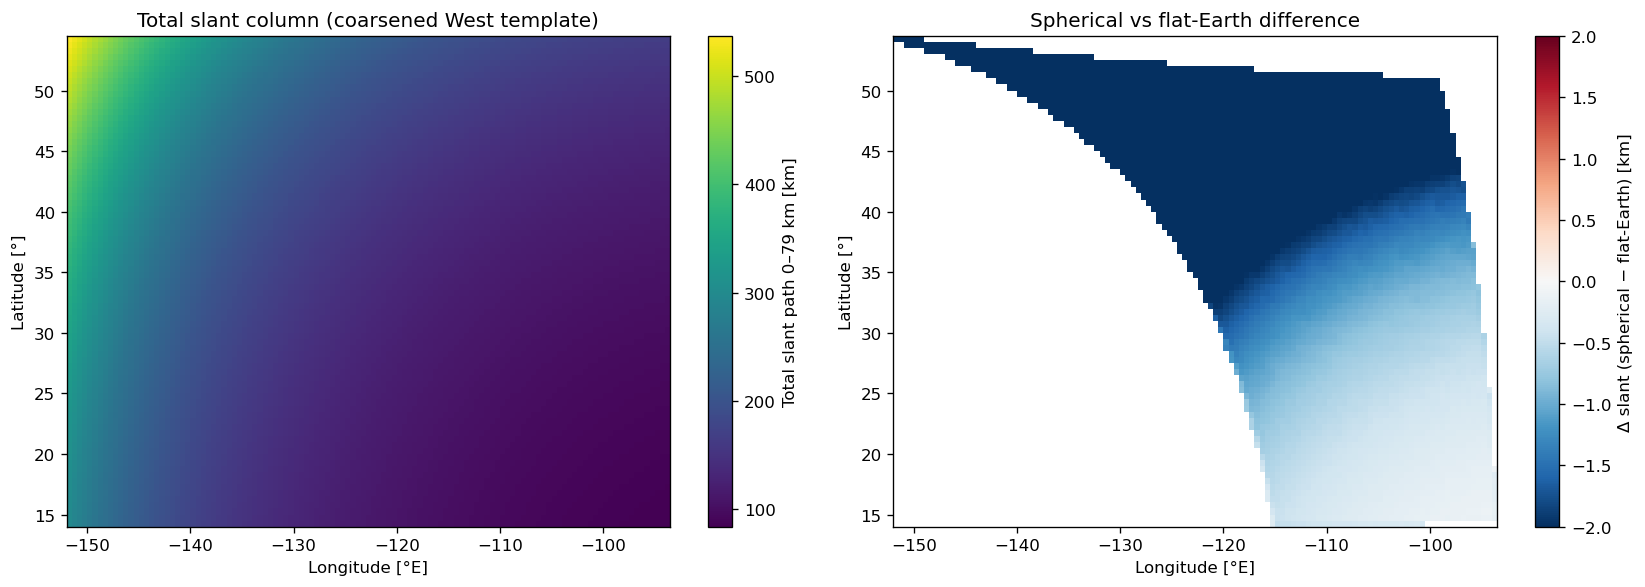

In [35]:
# Mean slant column (total path length through 0–79 km atmosphere)
total_slant = rays_c['slant_lengths'].sum(axis=1)
slant_2d    = np.full(cblk.shape, np.nan)
slant_2d[valid] = total_slant

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].pcolormesh(cblk['lons'], cblk['lats'], slant_2d,
                          cmap='viridis', shading='auto')
plt.colorbar(im0, ax=axes[0], label='Total slant path 0–79 km [km]')
axes[0].set_title('Total slant column (coarsened West template)')

secvza_2d = np.full(cblk.shape, np.nan)
secvza_2d[valid] = 1.0 / np.cos(np.deg2rad(cblk['vzas'][valid])) * 79.0
diff = slant_2d - secvza_2d
im1 = axes[1].pcolormesh(cblk['lons'], cblk['lats'], diff,
                          cmap='RdBu_r', shading='auto', vmin=-2, vmax=2)
plt.colorbar(im1, ax=axes[1], label='Δ slant (spherical − flat-Earth) [km]')
axes[1].set_title('Spherical vs flat-Earth difference')
for ax in axes:
    ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°]')
plt.tight_layout()

---
## 11 — Time-Stamping — Applying a Start Time

`template.stamp(t0_utc)` fills in all time-dependent fields for a given UTC
start time.  Only solar angles are recomputed (O(n_cols) sun-position calls);
all spatial geometry is reused from the template.

Each column receives its own UTC: `t0 + col_step × integration_time_s` for
W2E scanning (westernmost column observed first).

In [22]:
t_start = datetime(2020, 7, 1, 17, 30, 0)

t0_stamp = time.perf_counter()
stamped = {}
t_cursor = t_start
for name, tmpl in templates.items():
    stamped[name] = tmpl.stamp(t_cursor)
    # Advance clock by one full block width
    t_cursor += timedelta(seconds=tmpl.n_cols * sat.integration_time_s)
stamp_ms = (time.perf_counter() - t0_stamp) * 1e3

print(f"Three blocks stamped in {stamp_ms:.0f} ms  "
      f"(geometry was pre-built; only solar angles recomputed)")
print()
for name, blk in stamped.items():
    print(f"{name:8s}: {blk}")
    print(f"  SZA {blk['szas'].min():.1f}°–{blk['szas'].max():.1f}°  "
          f"t_start={blk.t_start_utc}  t_end={blk.t_end_utc}")

Three blocks stamped in 62 ms  (geometry was pre-built; only solar angles recomputed)

West    : ScanBlock(1000×402 px | lat=30.0° | lon=[-120.0°,-95.0°] | dur=66.8 min, t=2020-07-01T17:30Z, dir=W2E)
  SZA 0.0°–60.2°  t_start=2020-07-01 17:30:00  t_end=2020-07-01 18:36:50
Central : ScanBlock(1000×321 px | lat=30.0° | lon=[-95.0°,-75.0°] | dur=53.3 min, t=2020-07-01T18:37Z, dir=W2E)
  SZA 3.6°–42.1°  t_start=2020-07-01 18:37:00  t_end=2020-07-01 19:30:20
East    : ScanBlock(1000×241 px | lat=30.0° | lon=[-75.0°,-60.0°] | dur=40.0 min, t=2020-07-01T19:30Z, dir=W2E)
  SZA 32.9°–63.0°  t_start=2020-07-01 19:30:30  t_end=2020-07-01 20:10:30


Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


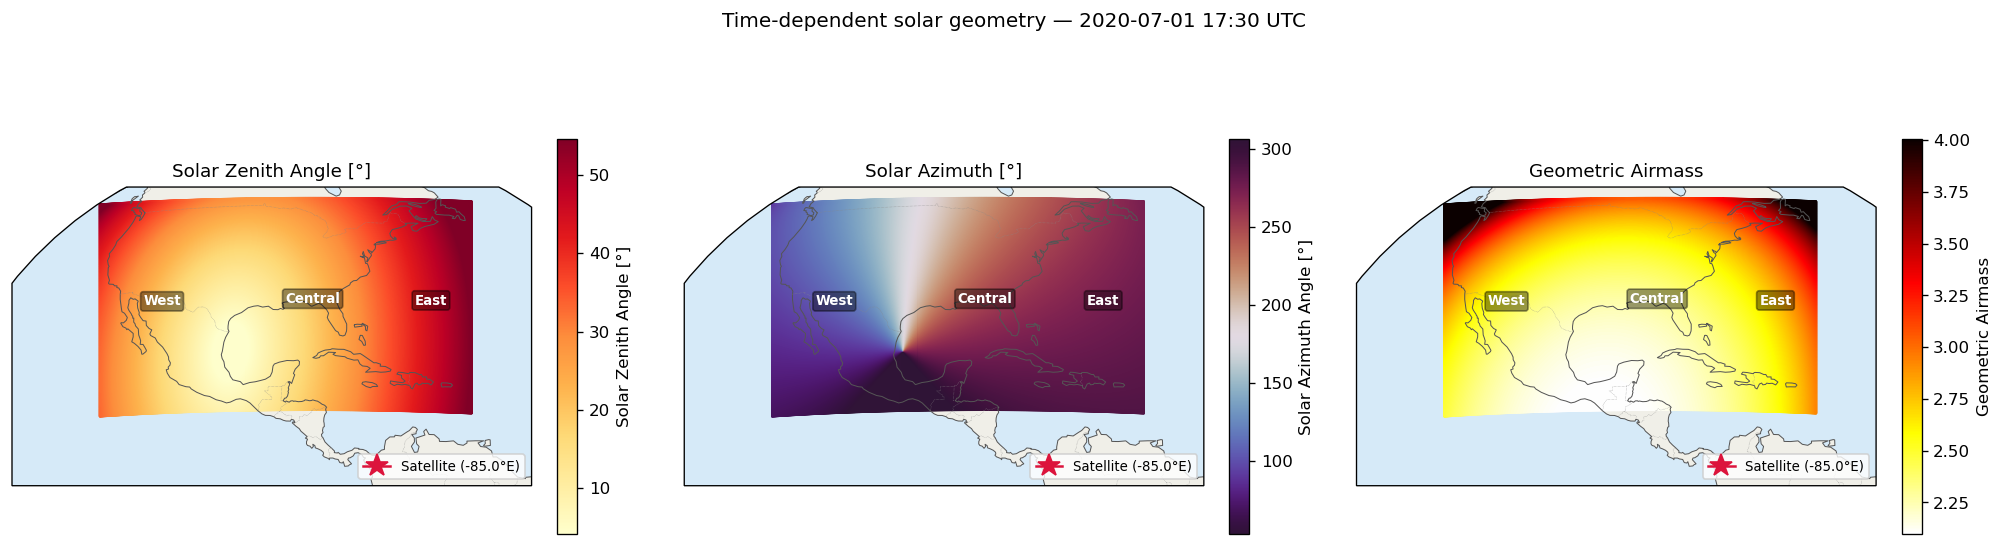

In [23]:
# Plot the time-dependent solar fields for the stamped blocks
stamped_list = list(stamped.values())
_geo = ccrs.Geostationary(central_longitude=sat_lon, satellite_height=35_786_000)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), subplot_kw={'projection': _geo})
fields  = ['szas', 'saas', 'airmass_geometric']
titles  = ['Solar Zenith Angle [°]', 'Solar Azimuth [°]', 'Geometric Airmass']
cmaps   = ['YlOrRd', 'twilight_shifted', 'hot_r']

for ax, fld, title, cm in zip(axes, fields, titles, cmaps):
    plot_scan_blocks(stamped_list, field=fld, mode='pixels',
                     ax=ax, cmap=cm, coastlines=True, block_labels=block_names,
                     title=title)
    ax.set_extent([-130, -55, 5, 55], crs=ccrs.PlateCarree())
plt.suptitle(f'Time-dependent solar geometry — {t_start.strftime("%Y-%m-%d %H:%M UTC")}',
             y=1.01)
plt.tight_layout()

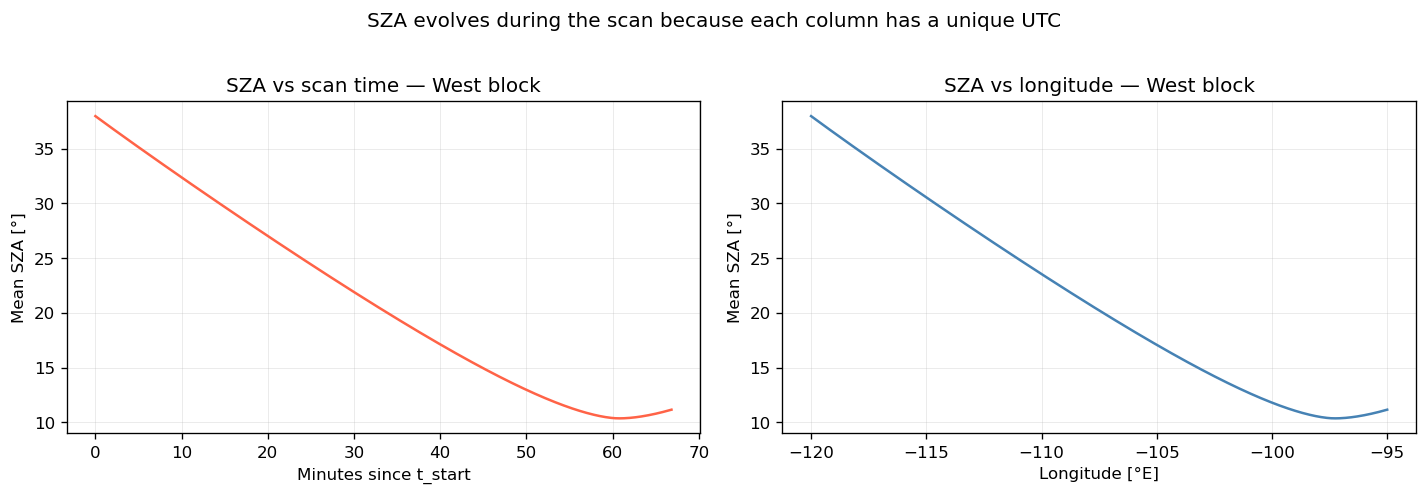

In [24]:
# Per-column time progression: how SZA changes across a scan
blk_w = stamped['West']
col_szas = blk_w['szas'].mean(axis=0)      # mean across slit rows
col_lons  = blk_w._meta['scan_lons']
col_times = [(t - t_start).total_seconds() / 60 for t in blk_w.col_times]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(col_times, col_szas, lw=1.5, color='tomato')
axes[0].set_xlabel('Minutes since t_start'); axes[0].set_ylabel('Mean SZA [°]')
axes[0].set_title('SZA vs scan time — West block')
axes[0].grid(True, lw=0.3, alpha=0.5)

axes[1].plot(col_lons, col_szas, lw=1.5, color='steelblue')
axes[1].set_xlabel('Longitude [°E]'); axes[1].set_ylabel('Mean SZA [°]')
axes[1].set_title('SZA vs longitude — West block')
axes[1].grid(True, lw=0.3, alpha=0.5)

plt.suptitle('SZA evolves during the scan because each column has a unique UTC', y=1.02)
plt.tight_layout()

---
## 12 — Solar Geometry Through the Day

Because stamp() only recomputes solar angles, it is inexpensive to apply the
same template at many different start times.  Here we trace the centre-pixel
SZA over the full diurnal cycle.

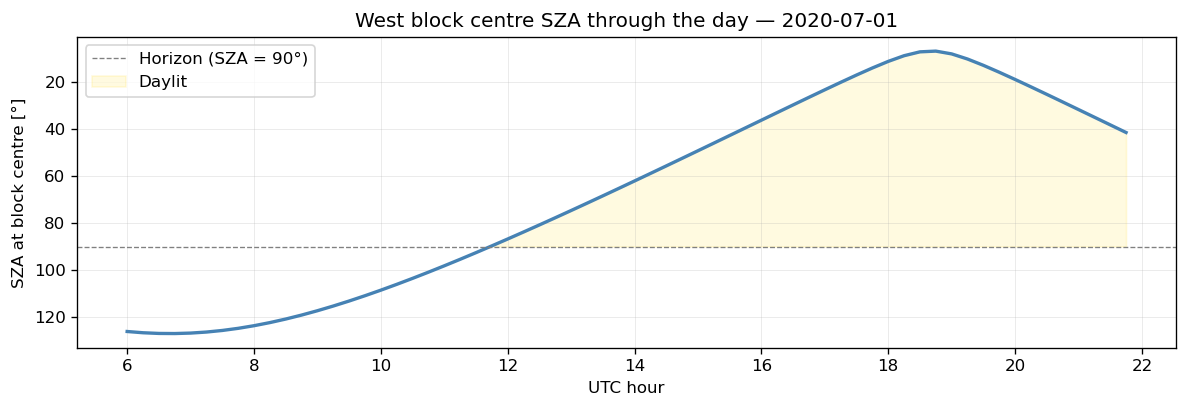

In [25]:
west_tmpl  = templates['West']
centre_row = west_tmpl.n_rows // 2
centre_col = west_tmpl.n_cols // 2

hours  = np.arange(6, 22, 0.25)   # 06:00–21:45 UTC in 15-min steps
szas_c = []
for h in hours:
    h_int, h_frac = int(h), h % 1
    dt = datetime(2020, 7, 1, h_int, int(h_frac * 60), 0)
    szas_c.append(west_tmpl.stamp(dt)['szas'][centre_row, centre_col])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(hours, szas_c, lw=2, color='steelblue')
ax.axhline(90, color='gray', lw=0.8, ls='--', label='Horizon (SZA = 90°)')
ax.fill_between(hours, szas_c, 90, where=[s < 90 for s in szas_c],
                alpha=0.12, color='gold', label='Daylit')
ax.set_xlabel('UTC hour'); ax.set_ylabel('SZA at block centre [°]')
ax.set_title('West block centre SZA through the day — 2020-07-01')
ax.legend(); ax.grid(True, lw=0.3, alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()

---
## 13 — Scan Direction — W2E vs E2W

The `scan_direction` argument (default `'W2E'`) controls which column is
observed first.  Spatial arrays always keep **col 0 = westernmost**; only the
UTC timestamps assigned to each column change.

- `'W2E'` — mirror steps west-to-east; t0 assigned to the westernmost column.
- `'E2W'` — mirror steps east-to-west; t0 assigned to the easternmost column.

A ~67-minute scan shifts the sun by ~15° SZA across the block, so the
direction matters for solar-angle accuracy.

In [26]:
t0_dir = datetime(2020, 7, 1, 14, 0, 0)   # 14:00 UTC

# Build the same region twice with opposite scan directions
tmpl_w2e = sat.build_scan_template(30.0, -120.0, -95.0, scan_direction='W2E')
tmpl_e2w = sat.build_scan_template(30.0, -120.0, -95.0, scan_direction='E2W')

blk_w2e = tmpl_w2e.stamp(t0_dir)
blk_e2w = tmpl_e2w.stamp(t0_dir)

print("W2E block:", blk_w2e)
print("E2W block:", blk_e2w)
print()
print(f"t_start / t_end identical: "
      f"{blk_w2e.t_start_utc == blk_e2w.t_start_utc}  "
      f"(same chronological span)")
print(f"Spatial geometry identical:  "
      f"lats={np.allclose(blk_w2e['lats'], blk_e2w['lats'])}  "
      f"vzas={np.allclose(blk_w2e['vzas'], blk_e2w['vzas'])}")
delta_sza = blk_w2e['szas'] - blk_e2w['szas']
print(f"ΔSZA (W2E − E2W): mean={delta_sza.mean():+.2f}°  "
      f"min={delta_sza.min():+.2f}°  max={delta_sza.max():+.2f}°")

W2E block: ScanBlock(1000×402 px | lat=30.0° | lon=[-120.0°,-95.0°] | dur=66.8 min, t=2020-07-01T14:00Z, dir=W2E)
E2W block: ScanBlock(1000×402 px | lat=30.0° | lon=[-120.0°,-95.0°] | dur=66.8 min, t=2020-07-01T14:00Z, dir=E2W)

t_start / t_end identical: True  (same chronological span)
Spatial geometry identical:  lats=True  vzas=True
ΔSZA (W2E − E2W): mean=-0.10°  min=-15.36°  max=+15.19°


In [27]:
# Per-column timestamps show the opposite ordering
n_cols = blk_w2e.n_cols
print(f"{'Col':>5}  {'W2E col_time':>22}  {'E2W col_time':>22}")
for j in [0, 1, n_cols//2, n_cols-2, n_cols-1]:
    print(f"{j:>5}  {str(blk_w2e.col_times[j]):>22}  {str(blk_e2w.col_times[j]):>22}")
print()
print(f"W2E: col 0 is earliest → {blk_w2e.col_times[0] < blk_w2e.col_times[-1]}")
print(f"E2W: col 0 is latest   → {blk_e2w.col_times[0] > blk_e2w.col_times[-1]}")

  Col            W2E col_time            E2W col_time
    0     2020-07-01 14:00:00     2020-07-01 15:06:50
    1     2020-07-01 14:00:10     2020-07-01 15:06:40
  201     2020-07-01 14:33:30     2020-07-01 14:33:20
  400     2020-07-01 15:06:40     2020-07-01 14:00:10
  401     2020-07-01 15:06:50     2020-07-01 14:00:00

W2E: col 0 is earliest → True
E2W: col 0 is latest   → True


Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


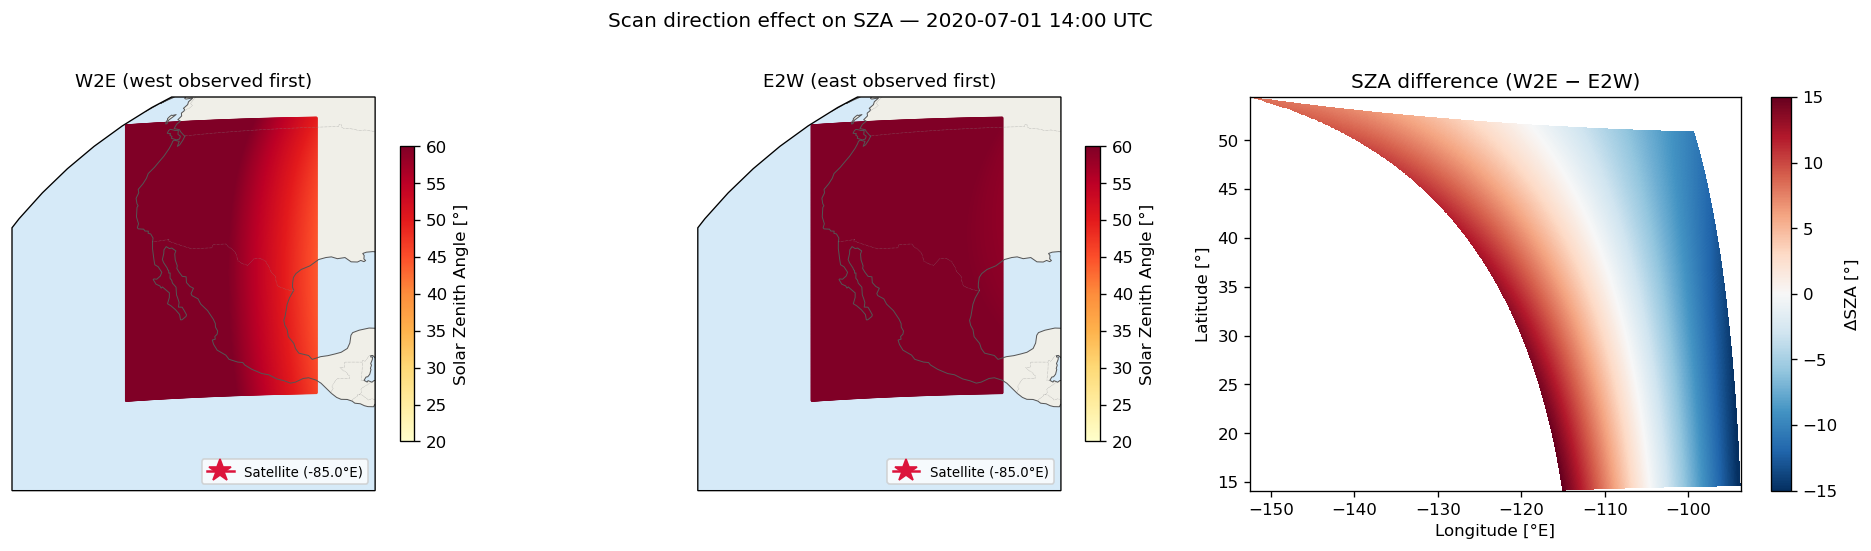

In [28]:
# SZA maps and difference for W2E vs E2W
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), subplot_kw={'projection': _geo})

for ax, blk, title in zip(axes[:2], [blk_w2e, blk_e2w],
        ['W2E (west observed first)', 'E2W (east observed first)']):
    plot_scan_blocks(blk, field='szas', mode='pixels', ax=ax, coastlines=True,
                     cmap='YlOrRd', vmin=20, vmax=60, title=title)
    ax.set_extent([-130, -90, 5, 55], crs=ccrs.PlateCarree())

# Difference panel on plain axes
axes[2].remove()
ax_diff = fig.add_subplot(1, 3, 3)
im = ax_diff.pcolormesh(blk_w2e['lons'], blk_w2e['lats'], delta_sza,
                         cmap='RdBu_r', shading='auto', vmin=-15, vmax=15)
plt.colorbar(im, ax=ax_diff, label='ΔSZA [°]')
ax_diff.set_title('SZA difference (W2E − E2W)')
ax_diff.set_xlabel('Longitude [°E]'); ax_diff.set_ylabel('Latitude [°]')
plt.suptitle(f'Scan direction effect on SZA — {t0_dir.strftime("%Y-%m-%d %H:%M UTC")}',
             y=1.01)
plt.tight_layout()

---
## 14 — Chaining Scan Templates

`chain_scan_blocks(templates, t0_utc, order=None)` stamps a sequence of
templates with consecutive start times, advancing the clock by one full block
width between blocks.  The `order` list can repeat keys for repeat-cycle
schedules.  Each block's `scan_direction` is inherited from its template.

In [29]:
# Rebuild templates with mixed scan directions
templates_mixed = {
    'West_W2E':    sat.build_scan_template(30.0, -120.0,  -95.0, scan_direction='W2E'),
    'Central_E2W': sat.build_scan_template(30.0,  -95.0,  -75.0, scan_direction='E2W'),
    'East_W2E':    sat.build_scan_template(30.0,  -75.0,  -60.0, scan_direction='W2E'),
}

# Two full cycles starting at 12:00 UTC
t_noon = datetime(2020, 7, 1, 12, 0, 0)
cycle = chain_scan_blocks(
    templates_mixed, t_noon,
    order=['West_W2E', 'Central_E2W', 'East_W2E',
           'West_W2E', 'Central_E2W', 'East_W2E'],
)

print(f"Chained {len(cycle)} blocks (2 repeat cycles, mixed scan directions)")
print()
for i, blk in enumerate(cycle):
    region = ['West', 'Central', 'East'][i % 3]
    print(f"  [{i}] {region:8s}  {blk.scan_direction}  "
          f"t_start={blk.t_start_utc}  "
          f"SZA {blk['szas'].min():.1f}°–{blk['szas'].max():.1f}°")

Chained 6 blocks (2 repeat cycles, mixed scan directions)

  [0] West      W2E  t_start=2020-07-01 12:00:00  SZA 68.4°–107.3°
  [1] Central   E2W  t_start=2020-07-01 13:07:00  SZA 50.4°–61.4°
  [2] East      W2E  t_start=2020-07-01 14:00:30  SZA 19.9°–45.2°
  [3] West      W2E  t_start=2020-07-01 14:40:40  SZA 35.2°–83.7°
  [4] Central   E2W  t_start=2020-07-01 15:47:40  SZA 18.0°–36.3°
  [5] East      W2E  t_start=2020-07-01 16:41:10  SZA 0.0°–38.2°


Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


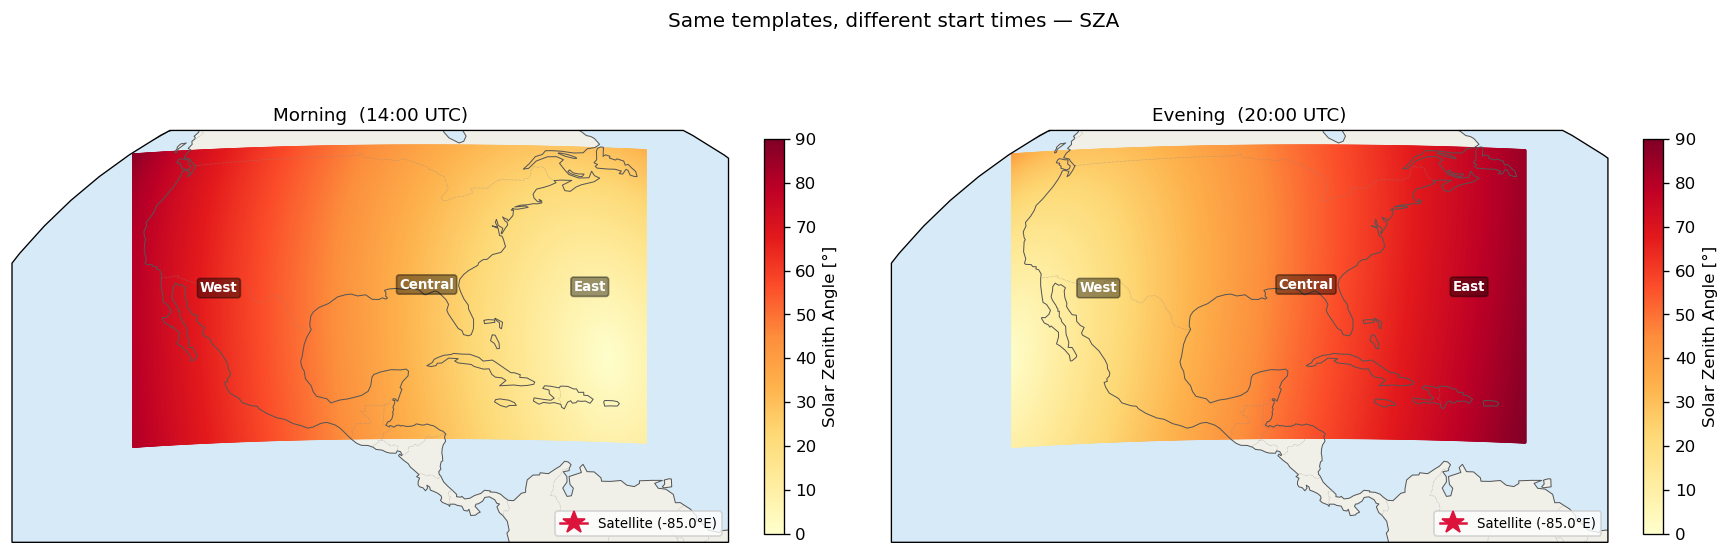

In [30]:
# Stamp the same templates at two different times of day and compare
t_morning = datetime(2020, 7, 1, 14, 0, 0)
t_evening  = datetime(2020, 7, 1, 20, 0, 0)

chain_morn = chain_scan_blocks(templates, t_morning)
chain_even = chain_scan_blocks(templates, t_evening)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': _geo})
for ax, chain, label in zip(axes, [chain_morn, chain_even],
        [f'Morning  ({t_morning.strftime("%H:%M UTC")})',
         f'Evening  ({t_evening.strftime("%H:%M UTC")})']):
    plot_scan_blocks(chain, field='szas', mode='pixels', ax=ax, cmap='YlOrRd',
                     vmin=0, vmax=90, coastlines=True,
                     block_labels=block_names, title=label)
    ax.set_extent([-130, -55, 5, 55], crs=ccrs.PlateCarree())
plt.suptitle('Same templates, different start times — SZA', y=1.01)
plt.tight_layout()

---
## 15 — Observation Sequence — Time-Ordered Timeline

`block.to_observation_sequence()` collapses the 2-D `(n_rows, n_cols)` arrays
into flat 1-D vectors of length `N = n_rows × n_cols` ordered by observation
time, following the `scan_direction` from the block's metadata.

Within each scan step (column) all slit rows are listed south-to-north — they
are simultaneous integrations.

Returned keys:
- `scan_step` — chronological step index (0 = first column observed)
- `scan_col`  — geographic column index (0 = westernmost)
- `slit_row`  — row within slit (0 = southernmost)
- `utc_times` — list of `datetime`, one per pixel

In [31]:
t0_seq = datetime(2020, 7, 1, 17, 30, 0)
blk_w2e = tmpl_w2e.stamp(t0_seq)   # West, W2E (tmpl built in §13)
blk_e2w = tmpl_e2w.stamp(t0_seq)   # West, E2W

seq_w2e = blk_w2e.to_observation_sequence()
seq_e2w = blk_e2w.to_observation_sequence()

print("Observation sequence keys:")
for k, v in seq_w2e.items():
    if v is None:
        print(f"  {k:22s}: None")
    elif isinstance(v, list):
        print(f"  {k:22s}: list[{len(v)}]  first={v[0]}")
    else:
        print(f"  {k:22s}: {v.shape}  dtype={v.dtype}")

Observation sequence keys:
  scan_step             : (402000,)  dtype=int64
  scan_col              : (402000,)  dtype=int64
  slit_row              : (402000,)  dtype=int64
  utc_times             : list[402000]  first=2020-07-01 17:30:00
  lats                  : (402000,)  dtype=float64
  lons                  : (402000,)  dtype=float64
  vzas                  : (402000,)  dtype=float64
  vaas                  : (402000,)  dtype=float64
  szas                  : (402000,)  dtype=float64
  saas                  : (402000,)  dtype=float64
  airmass_geometric     : (402000,)  dtype=float64
  relative_azimuth      : (402000,)  dtype=float64
  valid_mask            : (402000,)  dtype=bool
  sat_look_vecs         : (402000, 3)  dtype=float64
  gnd_ecef              : (402000, 3)  dtype=float64
  corner_lats           : (402000, 4)  dtype=float64
  corner_lons           : (402000, 4)  dtype=float64


In [32]:
# Verify time ordering and per-step uniqueness
times_w2e = np.array([(t - t0_seq).total_seconds() for t in seq_w2e['utc_times']])
times_e2w = np.array([(t - t0_seq).total_seconds() for t in seq_e2w['utc_times']])
print(f"W2E: utc_times monotone non-decreasing = {np.all(np.diff(times_w2e) >= 0)}")
print(f"E2W: utc_times monotone non-decreasing = {np.all(np.diff(times_e2w) >= 0)}")

n_cols_seq = blk_w2e.n_cols
w2e_ok = np.all(seq_w2e['scan_step'][::blk_w2e.n_rows]
                == seq_w2e['scan_col'][::blk_w2e.n_rows])
e2w_ok = np.all(seq_e2w['scan_step'][::blk_e2w.n_rows]
                == (n_cols_seq - 1 - seq_e2w['scan_col'][::blk_e2w.n_rows]))
print(f"W2E: scan_step == scan_col              → {w2e_ok}")
print(f"E2W: scan_step == (n_cols-1 - scan_col) → {e2w_ok}")

W2E: utc_times monotone non-decreasing = True
E2W: utc_times monotone non-decreasing = True
W2E: scan_step == scan_col              → True
E2W: scan_step == (n_cols-1 - scan_col) → True


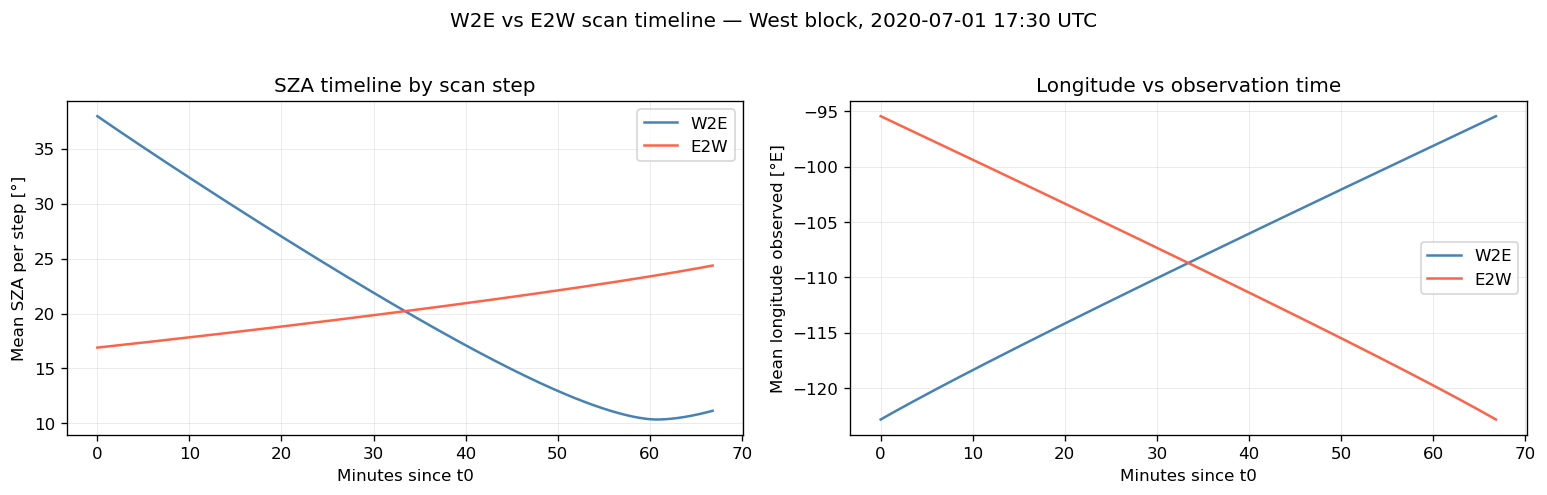

In [33]:
# Timeline plot: per-column mean SZA and longitude vs elapsed time
def col_mean_sza(seq, t_ref):
    n_steps   = seq['scan_step'].max() + 1
    szas_col  = np.array([seq['szas'][seq['scan_step'] == s].mean()
                          for s in range(n_steps)])
    times_col = np.array(
        [(seq['utc_times'][np.where(seq['scan_step'] == s)[0][0]] - t_ref
          ).total_seconds() / 60
         for s in range(n_steps)])
    lons_col  = np.array([seq['lons'][seq['scan_step'] == s].mean()
                          for s in range(n_steps)])
    return times_col, szas_col, lons_col

t_w, sza_w, lon_w = col_mean_sza(seq_w2e, t0_seq)
t_e, sza_e, lon_e = col_mean_sza(seq_e2w, t0_seq)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t_w, sza_w, label='W2E', color='steelblue', lw=1.5)
axes[0].plot(t_e, sza_e, label='E2W', color='tomato',    lw=1.5)
axes[0].set_xlabel('Minutes since t0'); axes[0].set_ylabel('Mean SZA per step [°]')
axes[0].set_title('SZA timeline by scan step')
axes[0].legend(); axes[0].grid(True, lw=0.3, alpha=0.5)

axes[1].plot(t_w, lon_w, label='W2E', color='steelblue', lw=1.5)
axes[1].plot(t_e, lon_e, label='E2W', color='tomato',    lw=1.5)
axes[1].set_xlabel('Minutes since t0'); axes[1].set_ylabel('Mean longitude observed [°E]')
axes[1].set_title('Longitude vs observation time')
axes[1].legend(); axes[1].grid(True, lw=0.3, alpha=0.5)

plt.suptitle(f'W2E vs E2W scan timeline — West block, {t0_seq.strftime("%Y-%m-%d %H:%M UTC")}',
             y=1.02)
plt.tight_layout()

In [34]:
# Chained multi-block timeline: concatenate observation sequences
chain_seq = chain_scan_blocks(templates_mixed, t0_utc=t0_seq)
seqs = [blk.to_observation_sequence() for blk in chain_seq]
N_total   = sum(len(s['scan_step']) for s in seqs)
all_times = sum([s['utc_times'] for s in seqs], [])
all_szas  = np.concatenate([s['szas'] for s in seqs])

offsets   = np.cumsum([0] + [s['scan_step'].max() + 1 for s in seqs[:-1]])
all_steps = np.concatenate([s['scan_step'] + off for s, off in zip(seqs, offsets)])

print(f"Total observations : {N_total:,}")
print(f"Global scan steps  : {all_steps.min()}–{all_steps.max()}")
print(f"UTC span           : {all_times[0]} → {all_times[-1]}")

# Plot per-step mean SZA across the full chain
times_min    = np.array([(t - all_times[0]).total_seconds() / 60 for t in all_times])
unique_steps = np.unique(all_steps)
step_times   = np.array([times_min[all_steps == s].mean() for s in unique_steps])
step_szas    = np.array([all_szas[all_steps == s].mean()  for s in unique_steps])

block_start_min = [(s['utc_times'][0] - all_times[0]).total_seconds() / 60 for s in seqs]
block_labels_ch = ['West
(W2E)', 'Central
(E2W)', 'East
(W2E)']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(step_times, step_szas, lw=1.5, color='steelblue')
for t_b, name in zip(block_start_min, block_labels_ch):
    ax.axvline(t_b, color='gray', lw=0.9, ls='--')
    ax.text(t_b + 0.3, step_szas.min() + 1, name, fontsize=8, color='dimgray')
ax.set_xlabel('Minutes since first observation')
ax.set_ylabel('Mean SZA per scan step [°]')
ax.set_title('Chained multi-block observation timeline')
ax.grid(True, lw=0.3, alpha=0.5)
plt.tight_layout()

SyntaxError: unterminated string literal (detected at line 22) (31649035.py, line 22)

---
## 16 — Sampling a 3-D Model Field (Regular Grid)

`model_sampler.py` bridges ScanBlocks with atmospheric model output.

- **`sample_field_along_rays`** — bilinearly interpolates a 3-D field at every
  ray-shell intercept for every pixel.
- **`integrate_along_rays`** — trapezoidal slant-column integration.
- **`pressure_to_alt_std_atm`** — converts pressure [hPa] to altitude [km].

Model sampling uses only spatial geometry (lats, lons, gnd_ecef, sat_look_vecs)
and can be run on a stamped block or a template.

In [ ]:
from model_sampler import (
    sample_field_along_rays,
    integrate_along_rays,
    interp_model_alts_to_block,
    pressure_to_alt_std_atm,
    alt_to_pressure_std_atm,
)

pres_hpa   = np.array([1000, 850, 700, 500, 300, 200, 100, 50, 20, 10], dtype=float)
level_alts = pressure_to_alt_std_atm(pres_hpa)
nlev       = len(pres_hpa)

print("Pressure levels and standard-atmosphere altitudes:")
for p, z in zip(pres_hpa, level_alts):
    print(f"  {p:6.0f} hPa  →  {z:.2f} km")

In [ ]:
# Synthetic global CO2 field on a 1° regular grid
model_lats = np.linspace(-90, 90, 181)
model_lons = np.linspace(-180, 180, 361)
nlat, nlon = len(model_lats), len(model_lons)

co2_profile  = 415.0 - 2.0 * (level_alts / level_alts.max())
lat_gradient = 0.02 * (model_lats - 30.0)
co2_2d    = co2_profile[:, np.newaxis] + lat_gradient[np.newaxis, :]
co2_field = np.broadcast_to(co2_2d[:, :, np.newaxis], (nlev, nlat, nlon)).copy()

print(f"CO2 field shape : {co2_field.shape}  (nlev, nlat, nlon)")
print(f"CO2 range       : {co2_field.min():.1f} – {co2_field.max():.1f} ppm")

# Sample along rays — use coarsened West template (spatial geometry only)
cblk  = coarse_templates['West']
valid = cblk['pixel_counts'] > 0

t0_samp = time.perf_counter()
result = sample_field_along_rays(cblk, sat, co2_field, model_lats, model_lons, level_alts)
elapsed = (time.perf_counter() - t0_samp) * 1e3
print(f"\nsampled shape : {result['sampled'].shape}  ({elapsed:.0f} ms)")

In [ ]:
column = integrate_along_rays(result['sampled'], result['slant_lengths'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im0 = axes[0].pcolormesh(cblk['lons'], cblk['lats'],
                          np.where(valid, result['sampled'][0], np.nan),
                          cmap='RdYlGn_r', shading='auto')
plt.colorbar(im0, ax=axes[0], label='CO₂ [ppm]')
axes[0].set_title('Sampled CO₂ at surface level (1000 hPa)')

im1 = axes[1].pcolormesh(cblk['lons'], cblk['lats'],
                          np.where(valid, column, np.nan),
                          cmap='RdYlGn_r', shading='auto')
plt.colorbar(im1, ax=axes[1], label='CO₂ [ppm · km]')
axes[1].set_title('Slant-column CO₂ integral')
for ax in axes:
    ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°]')
plt.suptitle('model_sampler — regular 1° global grid (West template, 0.5°×0.5°)', y=1.02)
plt.tight_layout()

---
## 17 — Per-Pixel Altitude Levels (Hybrid-Sigma / Terrain-Following)

Many models use terrain-following vertical coordinates where geometric altitude
varies spatially.  `interp_model_alts_to_block` interpolates a 3-D geopotential
height field to pixel centres, and `sample_field_along_rays` accepts that as
`level_alts_km`.

In [ ]:
# Synthetic terrain-following altitude field
terrain_km = (0.3 * np.cos(np.deg2rad(model_lats))[:, np.newaxis]
              * np.cos(np.deg2rad(model_lons))[np.newaxis, :])
alt_3d = level_alts[:, np.newaxis, np.newaxis] + terrain_km[np.newaxis, :, :]

t0_interp = time.perf_counter()
level_alts_px = interp_model_alts_to_block(alt_3d, model_lats, model_lons, cblk)
elapsed_interp = (time.perf_counter() - t0_interp) * 1e3

print(f"level_alts_px shape : {level_alts_px.shape}  (nlev, n_rows, n_cols)")
print(f"Surface alt range at pixels: "
      f"{np.nanmin(level_alts_px[0]):.3f} – {np.nanmax(level_alts_px[0]):.3f} km")
print(f"Elapsed: {elapsed_interp:.0f} ms")

In [ ]:
result_pp = sample_field_along_rays(cblk, sat, co2_field, model_lats, model_lons,
                                     level_alts_km=level_alts_px)
column_pp = integrate_along_rays(result_pp['sampled'], result_pp['slant_lengths'])
diff      = column_pp - column

print(f"Column difference (per-pixel − std-atm):  "
      f"min={np.nanmin(diff[valid]):.3f}  max={np.nanmax(diff[valid]):.3f}  "
      f"mean={np.nanmean(diff[valid]):.3f}  ppm·km")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im0 = axes[0].pcolormesh(cblk['lons'], cblk['lats'],
                          np.where(valid, level_alts_px[0], np.nan),
                          cmap='terrain', shading='auto')
plt.colorbar(im0, ax=axes[0], label='Surface level altitude [km]')
axes[0].set_title('Interpolated surface level altitude (per pixel)')

vabs = np.nanpercentile(np.abs(diff[valid]), 98)
im1 = axes[1].pcolormesh(cblk['lons'], cblk['lats'], np.where(valid, diff, np.nan),
                          cmap='RdBu_r', shading='auto', vmin=-vabs, vmax=vabs)
plt.colorbar(im1, ax=axes[1], label='Δ column [ppm · km]')
axes[1].set_title('Column difference: per-pixel levels − standard atmosphere')
for ax in axes:
    ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°]')
plt.tight_layout()

---
## 18 — Curvilinear Grid, 4-D Fields, and Limited-Area Domains

Regional models output fields on **curvilinear grids** (lat/lon both 2-D) and
as **4-D fields** `(ntime, nlev, ny, nx)`.  `sample_field_along_rays` handles
both.  Pixels whose ray intercepts fall outside the domain are flagged in
`outside_domain`.

In [ ]:
# Synthetic WRF-like curvilinear grid over CONUS
ny_wrf, nx_wrf = 60, 80
lon_1d = np.linspace(-125.0, -65.0, nx_wrf)
lat_1d = np.linspace(24.0, 50.0, ny_wrf)
lon_rect, lat_rect = np.meshgrid(lon_1d, lat_1d)
lon_2d = lon_rect + 0.01 * (lat_rect - 37.0)
lat_2d = lat_rect - 0.02 * (lon_rect - (-95.0))

print(f"WRF-like grid : {lat_2d.shape}  "
      f"lat {lat_2d.min():.2f}°–{lat_2d.max():.2f}°  "
      f"lon {lon_2d.min():.2f}°–{lon_2d.max():.2f}°")

# 4-D CO2 field: (ntime=2, nlev, ny, nx)
co2_wrf_t0 = (co2_profile[:, np.newaxis, np.newaxis]
              + 0.03 * (lat_2d - 37.0)[np.newaxis, :, :])
co2_wrf_4d = np.stack([co2_wrf_t0, co2_wrf_t0 + 2.0], axis=0)
print(f"4-D field shape : {co2_wrf_4d.shape}  (ntime, nlev, ny, nx)")

In [ ]:
t0_curv = time.perf_counter()
result_t0 = sample_field_along_rays(cblk, sat, co2_wrf_4d, lat_2d, lon_2d,
                                      level_alts, time_idx=0)
result_t1 = sample_field_along_rays(cblk, sat, co2_wrf_4d, lat_2d, lon_2d,
                                      level_alts, time_idx=1)
elapsed_curv = (time.perf_counter() - t0_curv) * 1e3

ood_pixel = result_t0['outside_domain'].all(axis=0)
inside    = valid & ~ood_pixel
col_t0    = integrate_along_rays(result_t0['sampled'], result_t0['slant_lengths'])
col_t1    = integrate_along_rays(result_t1['sampled'], result_t1['slant_lengths'])

print(f"Curvilinear sampling : {elapsed_curv:.0f} ms (2 time steps)")
print(f"Pixels outside domain: {ood_pixel[valid].sum()} / {valid.sum()} "
      f"({100*ood_pixel[valid].mean():.1f}%)")
print(f"Column t=0 (inside)  : {np.nanmean(col_t0[inside]):.2f} ± "
      f"{np.nanstd(col_t0[inside]):.2f} ppm·km")
print(f"Column change t1−t0  : {np.nanmean((col_t1 - col_t0)[inside]):.2f} ppm·km")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

im0 = axes[0].pcolormesh(cblk['lons'], cblk['lats'],
                          np.where(inside, col_t0, np.nan), cmap='RdYlGn_r', shading='auto')
plt.colorbar(im0, ax=axes[0], label='CO₂ [ppm · km]')
axes[0].set_title('WRF column (time 0)\ncurvilinear grid')

im1 = axes[1].pcolormesh(cblk['lons'], cblk['lats'],
                          np.where(inside, col_t1 - col_t0, np.nan),
                          cmap='RdBu', shading='auto', vmin=-5, vmax=5)
plt.colorbar(im1, ax=axes[1], label='Δ CO₂ [ppm · km]')
axes[1].set_title('Column change: time 1 − time 0\n(+2 ppm inside domain)')

ood_display = np.where(valid, ood_pixel.astype(float), np.nan)
im2 = axes[2].pcolormesh(cblk['lons'], cblk['lats'], ood_display,
                          cmap='bwr', shading='auto', vmin=0, vmax=1)
plt.colorbar(im2, ax=axes[2], label='1 = outside WRF domain')
axes[2].set_title('Outside-domain mask')

wrf_lons_b = np.concatenate([lon_2d[0,:], lon_2d[:,-1], lon_2d[-1,::-1], lon_2d[::-1,0]])
wrf_lats_b = np.concatenate([lat_2d[0,:], lat_2d[:,-1], lat_2d[-1,::-1], lat_2d[::-1,0]])
for ax in axes:
    ax.plot(wrf_lons_b, wrf_lats_b, 'k-', lw=1.0)
    ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°]')
plt.suptitle('model_sampler — WRF-like curvilinear grid, 4-D field, limited-area domain',
             y=1.02)
plt.tight_layout()